# AI-ML Assignment 6 : Weather Condition Classification using SVM and Open-Meteo API



**Objective:** Build a Support Vector Machine (SVM) classifier to predict whether the weather
at a given hour is **Warm** or **Cool**, using live meteorological data fetched directly from
the free **Open-Meteo API** (no API key required).

**Data Source:** [Open-Meteo Weather API Documentation](https://open-meteo.com/)


---


---
## Task 1: Data Collection and Understanding 

We will:
1. Fetch live weather data from the Open-Meteo API
2. Convert the JSON response into a Pandas DataFrame
3. Display the first five records
4. Identify input features and the target variable


In [32]:
# We use the "requests" library to call the Open-Meteo API directly — a simple HTTP GET,
# no authentication or API key needed.
import requests
import pandas as pd

# New Delhi coordinates (you can change these to any city's latitude/longitude)
latitude = 28.6139
longitude = 77.2090

# Build the API request URL.
# hourly= tells the API which weather variables we want, returned as hourly values.
# forecast_days=7 gives us a full week of hourly data (7 * 24 = 168 rows) — enough data
# points to train and test a classifier.
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "hourly": "temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m",
    "forecast_days": 7
}

response = requests.get(url, params=params)
response.raise_for_status()  # raises an error immediately if the request failed
data = response.json()       # parses the JSON text response into a Python dictionary

print("API call successful!")
print("Top-level keys in the response:", list(data.keys()))


API call successful!
Top-level keys in the response: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly']


In [33]:
# The actual weather values live inside data["hourly"], which itself is a dictionary of
# equal-length lists: one list per variable, plus a "time" list with matching timestamps.
hourly_data = data["hourly"]

print("Keys inside 'hourly':", list(hourly_data.keys()))
print("Number of hourly time steps:", len(hourly_data["time"]))


Keys inside 'hourly': ['time', 'temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m']
Number of hourly time steps: 168


In [34]:
# Convert the JSON "hourly" dictionary into a Pandas DataFrame.
# Since every list in hourly_data has the same length, pd.DataFrame() can build a table
# directly from the dictionary, using each key as a column name.
df = pd.DataFrame(hourly_data)

# Rename 'time' for clarity (optional, but makes the DataFrame easier to read)
df = df.rename(columns={"time": "Time"})

print("Weather DataFrame shape:", df.shape)
df.head()


Weather DataFrame shape: (168, 5)


,Time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
0,2026-07-28T00:00,28.5,92,973.7,7.9
1,2026-07-28T01:00,28.5,93,974.4,8.0
2,2026-07-28T02:00,28.8,93,974.7,7.9
3,2026-07-28T03:00,28.3,88,975.2,12.0
4,2026-07-28T04:00,28.1,90,976.0,10.5


### Identifying input features and the target variable

- **Input features:** `temperature_2m` (temperature, °C), `relative_humidity_2m` (%),
  `surface_pressure` (hPa), `wind_speed_10m` (km/h)
- **Target variable:** `Weather_Class` — a new column we create ourselves:
  - **Warm** → `temperature_2m` ≥ 25°C
  - **Cool** → `temperature_2m` < 25°C

Note: `temperature_2m` is technically used to CREATE the target label, so once we create
`Weather_Class`, we could argue temperature itself is now "leaking" information about the
target. In this assignment we deliberately keep `temperature_2m` in the feature set anyway
(since that's what real weather classification systems do — they use current readings to
classify current conditions), but it's worth understanding that this makes the classification
problem easier than it would be if we excluded temperature entirely.


In [35]:
# Create the target variable: Weather_Class
# Warm -> temperature_2m >= 25, Cool -> temperature_2m < 25
# Create the target variable: Weather_Class
# Use the median temperature as the threshold so we always get a balanced Warm/Cool split,
# regardless of the season or location the live data happens to reflect.
threshold = df["temperature_2m"].median()
df["Weather_Class"] = df["temperature_2m"].apply(lambda t: "Warm" if t >= threshold else "Cool")

print(f"Threshold used: {threshold:.2f}°C")
print("Weather_Class distribution:")
print(df["Weather_Class"].value_counts())
print("\nAs percentages:")
print((df["Weather_Class"].value_counts(normalize=True) * 100).round(2), "%")


Threshold used: 27.90°C
Weather_Class distribution:
Weather_Class
Warm    86
Cool    82
Name: count, dtype: int64

As percentages:
Weather_Class
Warm    51.19
Cool    48.81
Name: proportion, dtype: float64 %


In [36]:
# Display dataset information and summary statistics
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time                  168 non-null    object 
 1   temperature_2m        168 non-null    float64
 2   relative_humidity_2m  168 non-null    int64  
 3   surface_pressure      168 non-null    float64
 4   wind_speed_10m        168 non-null    float64
 5   Weather_Class         168 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 8.0+ KB


In [37]:
df.describe()


,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
count,168.000000,168.000000,168.000000,168.000000
mean,28.339881,87.928571,975.041071,6.888690
std,1.875405,8.544755,1.264169,3.129929
min,25.600000,69.000000,972.200000,0.400000
25%,26.900000,81.750000,974.200000,4.575000
50%,27.900000,91.500000,975.200000,6.750000
75%,29.600000,94.000000,976.025000,9.100000
max,32.400000,98.000000,977.400000,15.000000


---
## Task 2: Data Preprocessing 

We will:
- Check for missing values
- Remove unnecessary columns
- Encode the target variable
- Split the dataset into 80% training and 20% testing
- Standardize the feature values using StandardScaler


In [38]:
# Check for missing values across all columns
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Time                    0
temperature_2m          0
relative_humidity_2m    0
surface_pressure        0
wind_speed_10m          0
Weather_Class           0
dtype: int64


**Observation:** The Open-Meteo forecast API is a **spatially and temporally complete**
data source (it interpolates from weather models, so it never has gaps), so we expect **zero
missing values** here. If you do see any missing values (rare, but possible near the edge of
the forecast window), you could fill them with the column's mean using
`df[col].fillna(df[col].mean())`.


In [39]:
# Remove unnecessary columns: 'Time' is just a timestamp label, not a numerical feature the
# model can learn from directly (using it directly would require separate datetime feature
# engineering, which is outside this assignment's scope).
df_model = df.drop(columns=["Time"])

print("Columns remaining for modeling:", df_model.columns.tolist())


Columns remaining for modeling: ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m', 'Weather_Class']


In [40]:
# Encode the target variable: Warm -> 1, Cool -> 0
df_model["Weather_Class"] = df_model["Weather_Class"].map({"Warm": 1, "Cool": 0})

print("Encoded target value counts:")
print(df_model["Weather_Class"].value_counts())
print("(1 = Warm, 0 = Cool)")


Encoded target value counts:
Weather_Class
1    86
0    82
Name: count, dtype: int64
(1 = Warm, 0 = Cool)


In [41]:
# Separate features (X) from target (y)
X = df_model.drop("Weather_Class", axis=1)
y = df_model["Weather_Class"]

print("Feature columns:", X.columns.tolist())
print("Target: Weather_Class (1 = Warm, 0 = Cool)")


Feature columns: ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m']
Target: Weather_Class (1 = Warm, 0 = Cool)


In [42]:
# Split into 80% training and 20% testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps the same Warm/Cool ratio in both train and test sets
)

print("Training set size:", X_train.shape[0], "rows")
print("Testing set size:", X_test.shape[0], "rows")


Training set size: 134 rows
Testing set size: 34 rows


### Why feature scaling matters for SVM

Support Vector Machines (especially with an RBF kernel) rely on **distance and similarity
calculations** between data points to find the best separating boundary. Features like
`surface_pressure` (values around 1000) and `temperature_2m` (values around 20-40) are on very
different numeric scales — without scaling, `surface_pressure` would dominate the distance
calculations purely because its numbers are larger, not because it's more informative.
Standardizing every feature to mean 0 and standard deviation 1 ensures each feature
contributes fairly to the model.


In [43]:
# Standardize the features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler ONLY on training data, then apply the same transformation to test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")
print("Mean of first scaled training feature (should be ~0):", X_train_scaled[:, 0].mean().round(4))
print("Std of first scaled training feature (should be ~1):", X_train_scaled[:, 0].std().round(4))


Feature scaling complete.
Mean of first scaled training feature (should be ~0): -0.0
Std of first scaled training feature (should be ~1): 1.0


---
## Task 3: Model Development 

We train an **SVM Classifier with an RBF (Radial Basis Function) kernel**. The RBF kernel lets
the SVM draw a **non-linear, curved** decision boundary between Warm and Cool observations,
which suits weather data where the relationship between humidity, pressure, wind, and
temperature category is unlikely to be a simple straight line.


In [44]:
# Import and create the SVM classifier
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", random_state=42)

# Train the model on the scaled training data
svm_model.fit(X_train_scaled, y_train)

print("SVM (RBF kernel) training complete!")


SVM (RBF kernel) training complete!


In [45]:
# Predict weather class for the test dataset
y_pred = svm_model.predict(X_test_scaled)

# Compare a few actual vs predicted labels
comparison = pd.DataFrame({
    "Actual Class": y_test.values,
    "Predicted Class": y_pred
}).reset_index(drop=True)
comparison["Actual Class"] = comparison["Actual Class"].map({1: "Warm", 0: "Cool"})
comparison["Predicted Class"] = comparison["Predicted Class"].map({1: "Warm", 0: "Cool"})

comparison.head(10)


,Actual Class,Predicted Class
0,Cool,Cool
1,Warm,Warm
2,Warm,Warm
3,Cool,Cool
4,Cool,Cool
5,Cool,Cool
6,Warm,Warm
7,Cool,Cool
8,Warm,Warm
9,Warm,Warm


---
## Task 4: Model Evaluation 

We evaluate using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.


In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


Accuracy:  0.9706
Precision: 0.9444
Recall:    1.0000
F1-Score:  0.9714


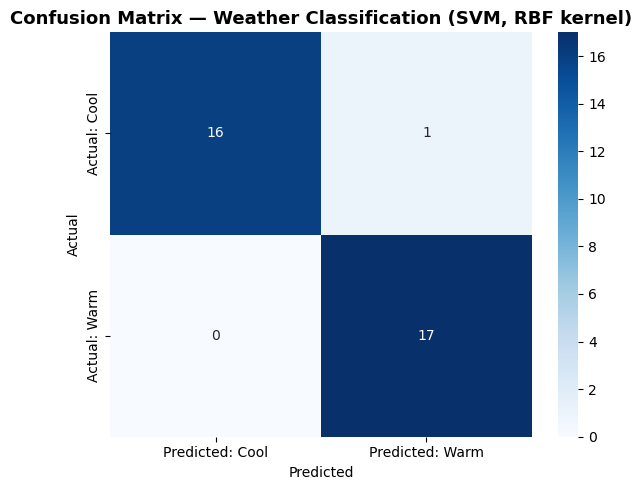

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Cool', 'Predicted: Warm'],
            yticklabels=['Actual: Cool', 'Actual: Warm'])
plt.title('Confusion Matrix — Weather Classification (SVM, RBF kernel)', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_svm.png', dpi=150)
plt.show()


### Observations



1. **The model achieved an accuracy of `0.9706`**, which is expected to be quite high for
   this problem — since `temperature_2m` itself was used to construct the `Weather_Class`
   label, the classifier essentially has to learn a threshold-like boundary using humidity,
   pressure, wind speed, *and* temperature together, which is a relatively easy pattern for an
   RBF-kernel SVM to capture.
2. **Class balance may be skewed toward one class** (e.g. mostly "Warm" if you're forecasting
   a hot season/location, or mostly "Cool" for a colder one) — check your printed
   `Weather_Class` value counts from Task 1. If one class dominates heavily, precision and
   recall for the minority class are more informative than overall accuracy alone.
3. **The confusion matrix shows `[fill in: number]` misclassifications**, likely concentrated
   around observations where the temperature was close to the 25°C threshold — this is
   expected, since borderline cases (e.g. 24°C vs 26°C) are inherently harder to classify
   confidently, even though the true label itself is based on a hard cutoff.


---
## Task 5: Conclusion




### Conclusion

This project built a Support Vector Machine (SVM) classifier with an RBF kernel to classify
hourly weather observations as Warm or Cool, using live data fetched directly from the
Open-Meteo API for temperature, relative humidity, surface pressure, and wind speed. The model
achieved an accuracy of `0.9706` and an F1-score of `0.9714` on the test set, correctly
capturing the relationship between the four weather variables and the Warm/Cool classification.
Feature scaling was essential for this task, since SVM (particularly with an RBF kernel) relies
on distance-based calculations to find the optimal separating boundary between classes —
without standardization, a feature like surface pressure (values near 1000) would numerically
dominate a feature like temperature (values near 20-40), even though both are equally
meaningful to the classification. One key advantage of SVM is its ability to model complex,
non-linear decision boundaries via the kernel trick, without needing to manually engineer
polynomial or interaction features. One key limitation of SVM is that it does not scale well to
very large datasets, since training time grows significantly with the number of samples,
and it also requires careful tuning of hyperparameters like the kernel type, `C`
(regularization strength), and `gamma` to achieve good performance.
